In [41]:
import sys, subprocess
print(sys.executable)
print(sys.version)
try:
    import pyspark
    print("pyspark", pyspark.__version__)
except Exception as e:
    print("Lỗi import pyspark:", e)
print(subprocess.run(["java", "-version"], capture_output=True, text=True).stderr)

/Users/quynhtien/venvs/ml/bin/python
3.14.7 (v3.14.7:823f0323ee6, Aug  5 2026, 07:07:01) [Clang 21.0.0 (clang-2100.1.1.101)]
pyspark 4.2.0
openjdk version "17.0.20.1" 2026-08-18
OpenJDK Runtime Environment Temurin-17.0.20.1+1 (build 17.0.20.1+1)
OpenJDK 64-Bit Server VM Temurin-17.0.20.1+1 (build 17.0.20.1+1, mixed mode, sharing)



In [1]:
import os, sys, subprocess
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["JAVA_HOME"] = subprocess.check_output(["/usr/libexec/java_home", "-v", "17"]).decode().strip()

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("test")
         .master("local[*]")
         .config("spark.driver.bindAddress", "127.0.0.1")
         .config("spark.driver.host", "127.0.0.1")
         .getOrCreate())

print("Spark:", spark.version)
print("count:", spark.range(1000).count())
print(spark.range(5).withColumn("sq", F.col("id") * F.col("id")).toPandas())
print(spark.sparkContext.parallelize(range(10)).map(lambda x: x * 2).sum())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/03 15:38:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.2.0
count: 1000
   id  sq
0   0   0
1   1   1
2   2   4
3   3   9
4   4  16


/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


90


In [5]:
import os, re

PROJECT = "/Users/quynhtien/Documents/Đồ án dự kiến"
RAW = os.path.join(PROJECT, "amazon-purchases.csv")
OUT = os.path.join(PROJECT, "Dulieulon")

print(os.path.exists(RAW), RAW)   # phải in True

df = spark.read.csv(RAW, header=True, inferSchema=True)
df = df.toDF(*[re.sub(r"[^0-9a-zA-Z]+", "_", c).strip("_") for c in df.columns])
df.printSchema()
df.show(5, truncate=40)
print("Rows:", df.count())

True /Users/quynhtien/Documents/Đồ án dự kiến/amazon-purchases.csv


root
 |-- Order_Date: date (nullable = true)
 |-- Purchase_Price_Per_Unit: double (nullable = true)
 |-- Quantity: double (nullable = true)
 |-- Shipping_Address_State: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- ASIN_ISBN_Product_Code: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Survey_ResponseID: string (nullable = true)

+----------+-----------------------+--------+----------------------+----------------------------------------+----------------------+-------------+-----------------+
|Order_Date|Purchase_Price_Per_Unit|Quantity|Shipping_Address_State|                                   Title|ASIN_ISBN_Product_Code|     Category|Survey_ResponseID|
+----------+-----------------------+--------+----------------------+----------------------------------------+----------------------+-------------+-----------------+
|2018-12-04|                   7.98|     1.0|                    NJ|SanDisk Ultra 16GB Class 10 SDHC UHS-...|            B0143RTB1

In [6]:
import os, pandas as pd
os.makedirs(f"{OUT}/audit", exist_ok=True)

df.cache()
n_total = df.count()
print("=" * 70, f"\nTỔNG SỐ DÒNG: {n_total:,}\n", "=" * 70, sep="")

# 1. Missing theo cột
print("\n[1] MISSING THEO CỘT")
miss = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]).toPandas().T
miss.columns = ["n_missing"]
miss["pct"] = (miss["n_missing"] / n_total * 100).round(3)
print(miss)
miss.to_csv(f"{OUT}/audit/missing_by_column.csv")

# 2. Khoảng thời gian và số dòng theo năm
print("\n[2] KHOẢNG THỜI GIAN")
df.select(F.min("Order_Date").alias("min_date"), F.max("Order_Date").alias("max_date")).show()
by_year = df.groupBy(F.year("Order_Date").alias("year")).count().orderBy("year")
by_year.show(30)
by_year.toPandas().to_csv(f"{OUT}/audit/rows_by_year.csv", index=False)

# 3. Giá trị bất thường và phân vị
print("\n[3] GIÁ TRỊ BẤT THƯỜNG")
df.select(
    F.sum((F.col("Purchase_Price_Per_Unit") <= 0).cast("int")).alias("price_le_0"),
    F.sum((F.col("Quantity") <= 0).cast("int")).alias("qty_le_0"),
    F.sum(F.col("Purchase_Price_Per_Unit").isNull().cast("int")).alias("price_null"),
    F.sum(F.col("Quantity").isNull().cast("int")).alias("qty_null"),
).show()
qs = [0.5, 0.95, 0.99, 0.999, 1.0]
q = df.approxQuantile(["Purchase_Price_Per_Unit", "Quantity"], qs, 0.001)
quant = pd.DataFrame(q, index=["price", "quantity"], columns=[f"p{x*100:g}" for x in qs])
print(quant)
quant.to_csv(f"{OUT}/audit/quantiles.csv")

# 4. Số user và phân bố số dòng/user
print("\n[4] USER")
n_users = df.select("Survey_ResponseID").distinct().count()
print("Số user:", f"{n_users:,}")
df.groupBy("Survey_ResponseID").count().select(
    F.min("count").alias("min"),
    F.expr("percentile_approx(count, 0.5)").alias("median"),
    F.expr("percentile_approx(count, 0.95)").alias("p95"),
    F.max("count").alias("max"),
).show()

# 5. Duplicate nguyên dòng (chỉ đo, chưa xóa)
print("\n[5] DUPLICATE")
n_dedup = df.dropDuplicates().count()
print(f"Duplicate rows: {n_total - n_dedup:,} ({(n_total - n_dedup)/n_total*100:.2f}%)")

# 6. Lọc từng bước + lưu bản sạch
print("\n[6] LỌC TỪNG BƯỚC")
steps = []
d = df;                                                                       steps.append(("Ban đầu", d.count()))
d = d.filter(F.col("Order_Date").between("2018-01-01", "2022-10-31"));        steps.append(("Trong 2018-01-01..2022-10-31", d.count()))
d = d.filter(F.col("Survey_ResponseID").isNotNull());                         steps.append(("User ID không null", d.count()))
d = d.filter(F.col("Purchase_Price_Per_Unit").isNotNull() & F.col("Quantity").isNotNull()); steps.append(("Giá và SL không null", d.count()))
d = d.filter((F.col("Purchase_Price_Per_Unit") > 0) & (F.col("Quantity") > 0)); steps.append(("Giá > 0 và SL > 0", d.count()))

audit = pd.DataFrame(steps, columns=["step", "rows"])
audit["dropped"] = (-audit["rows"].diff().fillna(0)).astype(int)
print(audit)
audit.to_csv(f"{OUT}/audit/row_filter_steps.csv", index=False)

clean = d.withColumn("Spend", F.col("Purchase_Price_Per_Unit") * F.col("Quantity"))
clean.write.mode("overwrite").parquet(f"{OUT}/audit/clean_transactions")
print("\nĐã lưu:", f"{OUT}/audit/clean_transactions")
print("Users sau lọc:", clean.select("Survey_ResponseID").distinct().count())

/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


TỔNG SỐ DÒNG: 1,850,717

[1] MISSING THEO CỘT
                         n_missing    pct
Order_Date                       0  0.000
Purchase_Price_Per_Unit          0  0.000
Quantity                         0  0.000
Shipping_Address_State       87812  4.745
Title                        89740  4.849
ASIN_ISBN_Product_Code         960  0.052
Category                     89557  4.839
Survey_ResponseID              144  0.008

[2] KHOẢNG THỜI GIAN
+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2018-01-01|2024-08-15|
+----------+----------+

+----+------+
|year| count|
+----+------+
|2018|225465|
|2019|266016|
|2020|409212|
|2021|467870|
|2022|442230|
|2023| 39923|
|2024|     1|
+----+------+


[3] GIÁ TRỊ BẤT THƯỜNG


/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


+----------+--------+----------+--------+
|price_le_0|qty_le_0|price_null|qty_null|
+----------+--------+----------+--------+
|         0|       0|         0|       0|
+----------+--------+----------+--------+



            p50    p95     p99    p99.9     p100
price     13.99  59.99  169.99  6398.95  6398.95
quantity   1.00   2.00    3.00   339.00   339.00

[4] USER
Số user: 16,072
+---+------+---+----+
|min|median|p95| max|
+---+------+---+----+
|  1|     2|646|5287|
+---+------+---+----+


[5] DUPLICATE


Duplicate rows: 11,695 (0.63%)

[6] LỌC TỪNG BƯỚC
                           step     rows  dropped
0                       Ban đầu  1850717        0
1  Trong 2018-01-01..2022-10-31  1737058   113659
2            User ID không null  1736922      136
3          Giá và SL không null  1736922        0
4             Giá > 0 và SL > 0  1736922        0



Đã lưu: /Users/quynhtien/Documents/Đồ án dự kiến/Dulieulon/audit/clean_transactions
Users sau lọc: 15390


In [7]:
print("[A] 10 DÒNG CHI TIÊU LỚN NHẤT")
clean.orderBy(F.desc("Spend")).select(
    "Survey_ResponseID","Order_Date","Purchase_Price_Per_Unit","Quantity","Spend","Title"
).show(10, truncate=35)

print("[B] 10 DÒNG SỐ LƯỢNG LỚN NHẤT")
clean.orderBy(F.desc("Quantity")).select(
    "Survey_ResponseID","Order_Date","Purchase_Price_Per_Unit","Quantity","Spend","Title"
).show(10, truncate=35)

print("[C] SỐ DÒNG THEO THÁNG QUANH MỐC CẮT (dữ liệu thô)")
(df.filter(F.col("Order_Date").between("2022-05-01", "2023-03-31"))
   .groupBy(F.date_format("Order_Date", "yyyy-MM").alias("ym"))
   .count().orderBy("ym").show(20))

print("[D] PHÂN BỐ SỐ NGÀY MUA (Frequency) MỖI USER")
u = clean.groupBy("Survey_ResponseID").agg(
    F.countDistinct("Order_Date").alias("freq"),
    F.sum("Spend").alias("spend"),
    F.avg("Quantity").alias("avg_qty"),
)
(u.withColumn("bucket", F.when(F.col("freq") == 1, "1")
                         .when(F.col("freq") == 2, "2")
                         .when(F.col("freq") <= 5, "3-5")
                         .when(F.col("freq") <= 20, "6-20")
                         .otherwise(">20"))
  .groupBy("bucket").agg(F.count("*").alias("n_users"),
                         F.round(F.avg("spend"), 1).alias("avg_spend"))
  .orderBy("n_users", ascending=False).show())

print("[E] PHÂN VỊ CỦA USER-LEVEL")
print(u.approxQuantile(["freq", "spend", "avg_qty"], [0.5, 0.9, 0.99, 1.0], 0.001))

[A] 10 DÒNG CHI TIÊU LỚN NHẤT
+-----------------+----------+-----------------------+--------+-------+-----------------------------------+
|Survey_ResponseID|Order_Date|Purchase_Price_Per_Unit|Quantity|  Spend|                              Title|
+-----------------+----------+-----------------------+--------+-------+-----------------------------------+
|R_3e8qukcDiaT0D0g|2020-02-16|                6398.95|     1.0|6398.95|LaCie 12big Thunderbolt 3 96TB S...|
|R_3lMSxgNkhRq4147|2022-06-26|                 759.99|     8.0|6079.92|Weize 12V 200Ah LiFePO4 Lithium ...|
|            Metro|2021-03-01|                 849.99|     7.0|5949.93|"Samsung Galaxy Z Flip (256GB, 8...|
|R_1NgAUlbpH2mgLYQ|2022-08-04|                 5949.0|     1.0| 5949.0|Sony VW325ES 4K HDR Home Theater...|
|R_3s6ANl73k2a38Oz|2021-04-27|                5499.99|     1.0|5499.99|                               NULL|
|R_3PUi8o2if0JqKfl|2022-06-16|                 4999.0|     1.0| 4999.0|Facial Beauty Bed Medical Aesthe...

In [8]:
valid = F.col("Survey_ResponseID").rlike(r"^R_[A-Za-z0-9]+$")

# --- Chẩn đoán ID rác ---
n_bad = df.filter(~valid | F.col("Survey_ResponseID").isNull()).count()
print(f"Dòng ID không hợp lệ: {n_bad:,} / {df.count():,}")
print("User hợp lệ  :", df.filter(valid).select("Survey_ResponseID").distinct().count())
print("User rác     :", df.filter(~valid).select("Survey_ResponseID").distinct().count())
df.filter(~valid).groupBy("Survey_ResponseID").count().orderBy(F.desc("count")).show(10, truncate=40)

# --- Dựng lại bản sạch ---
START, END = "2018-01-01", "2022-12-31"      # đổi END thành "2022-10-31" nếu muốn so sánh
steps = []
d = df;                                                                steps.append(("Ban đầu", d.count()))
d = d.filter(valid);                                                   steps.append(("ID dạng R_xxx hợp lệ", d.count()))
d = d.filter(F.col("Order_Date").between(START, END));                 steps.append((f"Trong {START}..{END}", d.count()))
d = d.filter((F.col("Purchase_Price_Per_Unit") > 0) & (F.col("Quantity") > 0)); steps.append(("Giá > 0 và SL > 0", d.count()))

audit = pd.DataFrame(steps, columns=["step", "rows"])
audit["dropped"] = (-audit["rows"].diff().fillna(0)).astype(int)
print(audit)
audit.to_csv(f"{OUT}/audit/row_filter_steps.csv", index=False)

clean = d.withColumn("Spend", F.col("Purchase_Price_Per_Unit") * F.col("Quantity"))
clean.write.mode("overwrite").parquet(f"{OUT}/audit/clean_transactions")
clean = spark.read.parquet(f"{OUT}/audit/clean_transactions")

# --- Phân bố Frequency sau khi sạch ---
u = clean.groupBy("Survey_ResponseID").agg(
    F.countDistinct("Order_Date").alias("freq"), F.sum("Spend").alias("spend"),
    F.avg("Quantity").alias("avg_qty"))
print("Users sau lọc:", u.count())
(u.withColumn("bucket", F.when(F.col("freq") == 1, "1").when(F.col("freq") == 2, "2")
                         .when(F.col("freq") <= 5, "3-5").when(F.col("freq") <= 20, "6-20").otherwise(">20"))
  .groupBy("bucket").agg(F.count("*").alias("n_users"), F.round(F.avg("spend"), 1).alias("avg_spend"))
  .orderBy("n_users", ascending=False).show())
print(u.approxQuantile(["freq", "spend", "avg_qty"], [0.5, 0.9, 0.99, 1.0], 0.001))

Dòng ID không hợp lệ: 39,479 / 1,850,717
User hợp lệ  : 5027
User rác     : 11044
+--------------------------------+-----+
|               Survey_ResponseID|count|
+--------------------------------+-----+
|                             RUG|  541|
|                         CURTAIN|  516|
|                         BLANKET|  362|
|PORTABLE_ELECTRONIC_DEVICE_COVER|  359|
|                   AMAZON_TABLET|  316|
|    Strong Seal on All Box Types|  298|
|                      TOY_FIGURE|  295|
|                  ADHESIVE_TAPES|  282|
|                            HOME|  251|
|             CELLULAR_PHONE_CASE|  245|
+--------------------------------+-----+
only showing top 10 rows
                           step     rows  dropped
0                       Ban đầu  1850717        0
1          ID dạng R_xxx hợp lệ  1811238    39479
2  Trong 2018-01-01..2022-12-31  1772132    39106
3             Giá > 0 và SL > 0  1772132        0


Users sau lọc: 5026
+------+-------+---------+
|bucket|n_users|avg_spend|
+------+-------+---------+
|   >20|   4445|   9282.1|
|  6-20|    471|    721.1|
|   3-5|     78|    222.2|
|     2|     21|    100.9|
|     1|     11|     49.3|
+------+-------+---------+

[[110.0, 365.0, 730.0, 1215.0], [5373.38, 19354.159999999996, 42984.49999999998, 108951.24999999997], [1.0425531914893618, 1.1529032258064515, 1.45, 4.552238805970149]]


In [9]:
import numpy as np, pandas as pd
os.makedirs(f"{OUT}/features", exist_ok=True)

clean = spark.read.parquet(f"{OUT}/audit/clean_transactions")
REF = "2022-12-31"          # phải trùng END ở bước lọc

def build_features(tx, ref=REF):
    u = tx.groupBy("Survey_ResponseID").agg(
        F.datediff(F.to_date(F.lit(ref)), F.max("Order_Date")).alias("Recency"),
        F.countDistinct("Order_Date").alias("Frequency"),
        F.sum("Spend").alias("Monetary"),
        F.countDistinct("ASIN_ISBN_Product_Code").alias("Unique_Products"),
        F.countDistinct("Category").alias("Category_Diversity"),
        F.countDistinct(F.date_format("Order_Date", "yyyy-MM")).alias("Active_Months"),
        F.avg("Quantity").alias("Avg_Quantity"),
        F.count("*").alias("Txn_Lines"),                      # chỉ để tham khảo
    )
    # winsorize Avg_Quantity ở p99
    cap = u.approxQuantile("Avg_Quantity", [0.99], 0.001)[0]
    u = u.withColumn("Avg_Quantity_w", F.least(F.col("Avg_Quantity"), F.lit(cap)))
    # log1p cho các biến lệch phải
    for c in ["Frequency", "Monetary", "Unique_Products"]:
        u = u.withColumn(c + "_log", F.log1p(c))
    print("Winsorize cap Avg_Quantity (p99):", round(cap, 3))
    return u

user = build_features(clean).cache()
print("Số user:", user.count())

# --- Mô tả và kiểm tra ---
pdf = user.toPandas()
cols = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]
print("\n[1] MÔ TẢ"); print(pdf[cols].describe(percentiles=[.5,.9,.99]).round(2).T)
print("\n[2] ĐỘ LỆCH (skew), trước và sau log")
for c in ["Frequency","Monetary","Unique_Products"]:
    print(f"{c:18s} raw={pdf[c].skew():6.2f}  log={pdf[c+'_log'].skew():6.2f}")
print("\n[3] TƯƠNG QUAN (Spearman)"); print(pdf[cols].corr(method="spearman").round(2))

# --- Lưu ---
user.write.mode("overwrite").parquet(f"{OUT}/features/user_features")
pdf.to_csv(f"{OUT}/features/user_features.csv", index=False)

# --- Đối chiếu bản Pandas cũ (nếu có) ---
old_path = os.path.join(PROJECT, "customer_features_rfm_behavior.csv")
if os.path.exists(old_path):
    old = pd.read_csv(old_path)
    print("\n[4] BẢN PANDAS CŨ:", old.shape, list(old.columns))

Winsorize cap Avg_Quantity (p99): 1.45


/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/quynhtien/venvs/ml/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Số user: 5026

[1] MÔ TẢ
                     count     mean      std   min      50%       90%  \
Recency             5026.0    59.21   143.25  0.00    21.00    114.00   
Frequency           5026.0   158.52   158.00  1.00   110.00    367.00   
Monetary            5026.0  8280.66  9248.31  4.99  5393.56  19421.92   
Unique_Products     5026.0   295.24   326.79  0.00   196.50    679.00   
Category_Diversity  5026.0   126.91   100.52  0.00   104.00    266.50   
Active_Months       5026.0    38.63    17.43  1.00    42.00     59.00   
Avg_Quantity        5026.0     1.07     0.14  1.00     1.04      1.15   

                         99%        max  
Recency               765.50    1758.00  
Frequency             755.50    1215.00  
Monetary            43293.62  108951.25  
Unique_Products      1547.25    4141.00  
Category_Diversity    440.00     668.00  
Active_Months          60.00      60.00  
Avg_Quantity            1.47       4.55  

[2] ĐỘ LỆCH (skew), trước và sau log
Frequency       

Xong A_RFM
Xong B_RFM_Behavior
         model  k  seed_ari_mean  seed_ari_min  boot_ari_mean  boot_ari_min
         A_RFM  2          1.000         1.000          0.982         0.967
         A_RFM  3          0.722         0.413          0.910         0.431
         A_RFM  4          0.995         0.990          0.974         0.923
         A_RFM  5          0.670         0.418          0.824         0.412
         A_RFM  6          0.775         0.451          0.924         0.833
         A_RFM  7          0.960         0.914          0.940         0.804
         A_RFM  8          0.693         0.543          0.779         0.520
B_RFM_Behavior  2          0.997         0.995          0.990         0.971
B_RFM_Behavior  3          0.683         0.340          0.978         0.937
B_RFM_Behavior  4          0.658         0.371          0.974         0.945
B_RFM_Behavior  5          0.768         0.410          0.933         0.845
B_RFM_Behavior  6          0.726         0.416          0

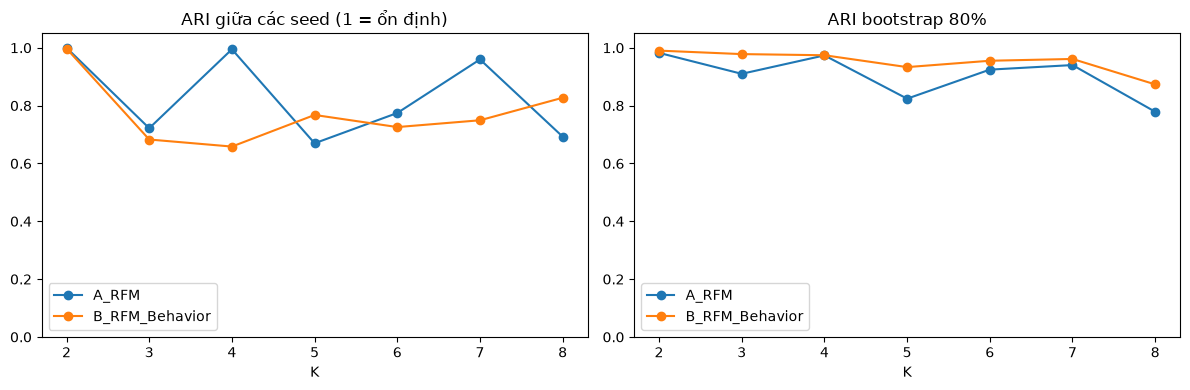


=== A_RFM, K=3 (median theo cluster) ===
         n_users  share  Recency  Frequency  Monetary  Unique_Products  Category_Diversity  Active_Months  Avg_Quantity
cluster                                                                                                                
0           1369  0.272     55.0       24.0   1070.90             43.0                28.0           16.0          1.02
1           1439  0.286      3.0      227.0  11417.35            404.0               184.0           55.0          1.06
2           2218  0.441     34.0      125.0   6201.55            229.0               120.0           46.0          1.05

=== A_RFM, K=4 (median theo cluster) ===
         n_users  share  Recency  Frequency  Monetary  Unique_Products  Category_Diversity  Active_Months  Avg_Quantity
cluster                                                                                                                
0           1616  0.322     30.0       52.0   2476.54             91.5      

In [11]:
from itertools import combinations
from sklearn.cluster import KMeans as SKMeans
os.makedirs(f"{OUT}/stability", exist_ok=True); os.makedirs(f"{OUT}/profiling", exist_ok=True)

STAB_MODELS = ["A_RFM", "B_RFM_Behavior"]
KS, SEEDS = range(2, 9), list(range(1, 11))

def spark_labels(data, k, seed):
    m = KMeans(k=k, seed=seed, featuresCol="features", maxIter=100).fit(data)
    rows = m.transform(data).select("Survey_ResponseID", "prediction").collect()
    rows.sort(key=lambda r: r["Survey_ResponseID"])
    return np.array([r["prediction"] for r in rows])

def boot_ari(X, k, B=30):
    ref = SKMeans(k, n_init=10, random_state=0).fit(X).labels_
    rng, out = np.random.default_rng(0), []
    for b in range(B):
        idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
        m = SKMeans(k, n_init=10, random_state=b).fit(X[idx])
        out.append(adjusted_rand_score(ref, m.predict(X)))
    return np.mean(out), np.min(out)

# ---- 1. Stability theo seed (Spark) và theo bootstrap (dữ liệu) ----
stab = []
for name in STAB_MODELS:
    data = prepare(MODELS[name])
    for k in KS:
        labs = [spark_labels(data, k, s) for s in SEEDS]
        ari = [adjusted_rand_score(a, b) for a, b in combinations(labs, 2)]
        bm, bmin = boot_ari(Xs[name], k)
        stab.append(dict(model=name, k=k, seed_ari_mean=np.mean(ari), seed_ari_min=np.min(ari),
                         boot_ari_mean=bm, boot_ari_min=bmin))
    print("Xong", name)
stab = pd.DataFrame(stab); stab.to_csv(f"{OUT}/stability/stability.csv", index=False)
print(stab.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name in STAB_MODELS:
    s = stab[stab.model == name]
    ax[0].plot(s.k, s.seed_ari_mean, marker="o", label=name); ax[1].plot(s.k, s.boot_ari_mean, marker="o", label=name)
ax[0].set_title("ARI giữa các seed (1 = ổn định)"); ax[1].set_title("ARI bootstrap 80%")
for a in ax: a.set_xlabel("K"); a.legend(); a.set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig(f"{OUT}/stability/stability.png", dpi=150); plt.show()

# ---- 2. Profile (giá trị gốc, dùng median vì dữ liệu lệch) ----
pdf = pdf.sort_values("Survey_ResponseID").reset_index(drop=True)
raw_cols = ["Recency", "Frequency", "Monetary", "Unique_Products", "Category_Diversity", "Active_Months", "Avg_Quantity"]
for name in STAB_MODELS:
    for k in [3, 4]:
        d = pdf.copy(); d["cluster"] = labels[(name, k)]
        prof = d.groupby("cluster")[raw_cols].median().round(2)
        prof.insert(0, "n_users", d.cluster.value_counts().sort_index())
        prof.insert(1, "share", (prof.n_users / len(d)).round(3))
        prof.to_csv(f"{OUT}/profiling/profile_{name}_k{k}.csv")
        print(f"\n=== {name}, K={k} (median theo cluster) ==="); print(prof.to_string())
print("\nMedian toàn bộ:", pdf[raw_cols].median().round(2).to_dict())

In [12]:
os.makedirs(f"{OUT}/final", exist_ok=True); os.makedirs(f"{OUT}/models", exist_ok=True)
pdf = pdf.sort_values("Survey_ResponseID").reset_index(drop=True)
raw_cols = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]
K_FINAL, N_SEEDS = 4, list(range(1, 31))

def fit_best(name, k=K_FINAL):
    data = prepare(MODELS[name])
    runs = []
    for s in N_SEEDS:
        m = KMeans(k=k, seed=s, featuresCol="features", maxIter=100).fit(data)
        lab = np.array([r["prediction"] for r in sorted(
            m.transform(data).select("Survey_ResponseID", "prediction").collect(),
            key=lambda r: r["Survey_ResponseID"])])
        runs.append(dict(seed=s, cost=m.summary.trainingCost, model=m, labels=lab))
    best = min(runs, key=lambda r: r["cost"])
    return best, runs

summary, finals = [], {}
for name in ["A_RFM", "B_RFM_Behavior"]:
    best, runs = fit_best(name)
    costs = np.array([r["cost"] for r in runs])
    ari_vs_best = np.array([adjusted_rand_score(best["labels"], r["labels"]) for r in runs])
    print(f"\n===== {name}, K={K_FINAL} =====")
    print(f"Seed tốt nhất: {best['seed']} | WSSSE min={costs.min():.1f}, max={costs.max():.1f}, "
          f"số mức WSSSE khác nhau={len(np.unique(costs.round(0)))}")
    print(f"Số seed (trên {len(runs)}) có ARI > 0.9 so với mô hình tốt nhất: {(ari_vs_best > 0.9).sum()}")

    # Kiểm tra nhóm "mua nhiều đơn vị" (Avg_Quantity cao, nhỏ) có xuất hiện ở từng seed không
    found = 0
    for r in runs:
        d = pdf.assign(c=r["labels"]).groupby("c").agg(q=("Avg_Quantity", "median"), n=("Avg_Quantity", "size"))
        found += int(((d.q > 1.2) & (d.n / len(pdf) < 0.12)).any())
    print(f"Số seed có nhóm nhỏ Avg_Quantity median > 1.2: {found}/{len(runs)}")

    # Đánh số lại cluster theo Monetary tăng dần để nhãn nhất quán
    d = pdf.assign(cluster_raw=best["labels"])
    order = d.groupby("cluster_raw")["Monetary"].median().sort_values().index.tolist()
    remap = {old: new for new, old in enumerate(order)}
    d["cluster"] = d["cluster_raw"].map(remap)

    prof = d.groupby("cluster")[raw_cols].median().round(2)
    prof.insert(0, "n_users", d.cluster.value_counts().sort_index())
    prof.insert(1, "share", (prof.n_users / len(d)).round(3))
    idx = (d.groupby("cluster")[raw_cols].mean() / d[raw_cols].mean()).round(2).add_suffix("_index")
    prof = prof.join(idx)
    print(prof.to_string())

    d.drop(columns="cluster_raw").to_csv(f"{OUT}/final/user_clusters_{name}.csv", index=False)
    prof.to_csv(f"{OUT}/profiling/cluster_profile_{name}.csv")
    best["model"].write().overwrite().save(f"{OUT}/models/kmeans_{name}_k{K_FINAL}")
    pd.Series(remap).to_csv(f"{OUT}/models/label_map_{name}.csv", header=["new_label"])
    summary.append(dict(model=name, best_seed=best["seed"], wssse=costs.min(),
                        seeds_ari_gt_0_9=int((ari_vs_best > 0.9).sum()), niche_found=found))
    finals[name] = d

pd.DataFrame(summary).to_csv(f"{OUT}/final/final_model_summary.csv", index=False)
ab = adjusted_rand_score(finals["A_RFM"]["cluster"], finals["B_RFM_Behavior"]["cluster"])
print(f"\nARI giữa A và B (mô hình cuối, K={K_FINAL}):", round(ab, 3))


===== A_RFM, K=4 =====
Seed tốt nhất: 21 | WSSSE min=4356.1, max=4356.2, số mức WSSSE khác nhau=1
Số seed (trên 30) có ARI > 0.9 so với mô hình tốt nhất: 30
Số seed có nhóm nhỏ Avg_Quantity median > 1.2: 0/30
         n_users  share  Recency  Frequency  Monetary  Unique_Products  Category_Diversity  Active_Months  Avg_Quantity  Recency_index  Frequency_index  Monetary_index  Unique_Products_index  Category_Diversity_index  Active_Months_index  Avg_Quantity_index
cluster                                                                                                                                                                                                                                                          
0            604  0.120    151.5       12.0    541.80             20.0                14.0            9.0          1.00           4.55             0.09            0.08                   0.08                      0.13                 0.25                0.98
1           1615

In [1]:
import pandas, pyarrow
print(pandas.__version__, pyarrow.__version__)   # kỳ vọng: 2.3.3 25.0.1

2.3.3 25.0.1


In [2]:
import os, sys, subprocess, re
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["JAVA_HOME"] = subprocess.check_output(["/usr/libexec/java_home", "-v", "17"]).decode().strip()

from pyspark.sql import SparkSession, functions as F
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler as SKScaler
from sklearn.cluster import KMeans as SKMeans
from sklearn.metrics import adjusted_rand_score

spark = (SparkSession.builder.appName("AmazonSegmentation").master("local[*]")
         .config("spark.driver.bindAddress", "127.0.0.1").config("spark.driver.host", "127.0.0.1")
         .config("spark.driver.memory", "8g").config("spark.sql.shuffle.partitions", "32")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

PROJECT = "/Users/quynhtien/Documents/Đồ án dự kiến"
OUT = os.path.join(PROJECT, "Dulieulon")
K_FINAL = 4

clean = spark.read.parquet(f"{OUT}/audit/clean_transactions")   # không cache

pdf = pd.read_csv(f"{OUT}/features/user_features.csv").sort_values("Survey_ResponseID").reset_index(drop=True)
pdf["Recency_log"] = np.log1p(pdf.Recency)
pdf["Category_Diversity_log"] = np.log1p(pdf.Category_Diversity)

A = ["Recency_log", "Frequency_log", "Monetary_log"]
MODELS = {"A_RFM": A,
          "B_RFM_Behavior": A + ["Unique_Products_log", "Category_Diversity_log", "Active_Months", "Avg_Quantity_w"]}
Xs = {n: SKScaler().fit_transform(pdf[c]) for n, c in MODELS.items()}
finals = {n: pd.read_csv(f"{OUT}/final/user_clusters_{n}.csv").sort_values("Survey_ResponseID").reset_index(drop=True)
          for n in MODELS}

def build_features(tx, ref="2022-12-31"):
    u = tx.groupBy("Survey_ResponseID").agg(
        F.datediff(F.to_date(F.lit(ref)), F.max("Order_Date")).alias("Recency"),
        F.countDistinct("Order_Date").alias("Frequency"),
        F.sum("Spend").alias("Monetary"),
        F.countDistinct("ASIN_ISBN_Product_Code").alias("Unique_Products"),
        F.countDistinct("Category").alias("Category_Diversity"),
        F.countDistinct(F.date_format("Order_Date", "yyyy-MM")).alias("Active_Months"),
        F.avg("Quantity").alias("Avg_Quantity"), F.count("*").alias("Txn_Lines"))
    cap = u.approxQuantile("Avg_Quantity", [0.99], 0.001)[0]
    u = u.withColumn("Avg_Quantity_w", F.least(F.col("Avg_Quantity"), F.lit(cap)))
    for c in ["Frequency", "Monetary", "Unique_Products"]:
        u = u.withColumn(c + "_log", F.log1p(c))
    return u

print(len(pdf), {n: len(d) for n, d in finals.items()})   # kỳ vọng: 5026 {'A_RFM': 5026, 'B_RFM_Behavior': 5026}

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/03 16:05:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.2.0
5026 {'A_RFM': 5026, 'B_RFM_Behavior': 5026}


In [3]:
def cluster_variant(tx_v, ref, min_freq, name):
    u = build_features(tx_v, ref=ref).toPandas().sort_values("Survey_ResponseID").reset_index(drop=True)
    if min_freq: u = u[u.Frequency > min_freq].reset_index(drop=True)
    u["Recency_log"] = np.log1p(u.Recency); u["Category_Diversity_log"] = np.log1p(u.Category_Diversity)
    X = SKScaler().fit_transform(u[MODELS[name]])
    u["c"] = SKMeans(K_FINAL, n_init=20, random_state=0).fit_predict(X)
    return u[["Survey_ResponseID", "c"]]

variants = {
    "baseline_sklearn": (clean, "2022-12-31", 0),
    "bo_duplicate": (clean.dropDuplicates(), "2022-12-31", 0),
    "moc_2022-10-31": (clean.filter(F.col("Order_Date") <= "2022-10-31"), "2022-10-31", 0),
    "bo_user_<=2_ngay": (clean, "2022-12-31", 2),
}
out, path = [], f"{OUT}/final/robustness.csv"
for vname, (tx_v, ref, mf) in variants.items():
    for mname in MODELS:
        v = cluster_variant(tx_v, ref, mf, mname).merge(
            finals[mname][["Survey_ResponseID", "cluster"]], on="Survey_ResponseID")
        out.append(dict(model=mname, variant=vname, n_common=len(v),
                        ARI_vs_final=round(adjusted_rand_score(v.cluster, v.c), 3)))
        pd.DataFrame(out).to_csv(path, index=False)
    print("Xong", vname)
print(pd.DataFrame(out).to_string(index=False))

Xong baseline_sklearn


Xong bo_duplicate


Xong moc_2022-10-31
Xong bo_user_<=2_ngay
         model          variant  n_common  ARI_vs_final
         A_RFM baseline_sklearn      5026         0.991
B_RFM_Behavior baseline_sklearn      5026         1.000
         A_RFM     bo_duplicate      5026         0.992
B_RFM_Behavior     bo_duplicate      5026         0.971
         A_RFM   moc_2022-10-31      5015         0.311
B_RFM_Behavior   moc_2022-10-31      5015         0.797
         A_RFM bo_user_<=2_ngay      4994         0.881
B_RFM_Behavior bo_user_<=2_ngay      4994         0.895


In [4]:
tx_v = clean.filter(F.col("Order_Date") <= "2022-10-31")
u = build_features(tx_v, ref="2022-10-31").toPandas().sort_values("Survey_ResponseID").reset_index(drop=True)
u["Recency_log"] = np.log1p(u.Recency); u["Category_Diversity_log"] = np.log1p(u.Category_Diversity)
raw = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]

print("Median Recency: mốc 12-31 =", pdf.Recency.median(), "| mốc 10-31 =", u.Recency.median())

# Profile của A ở mốc 10-31 (K=4) và bảng chéo với nhãn cuối
XA = SKScaler().fit_transform(u[MODELS["A_RFM"]])
u["c"] = SKMeans(4, n_init=20, random_state=0).fit_predict(XA)
prof = u.groupby("c")[raw].median().round(1); prof.insert(0, "n", u.c.value_counts().sort_index())
print("\nProfile A, mốc 10-31, K=4:\n", prof.to_string())
m = u.merge(finals["A_RFM"][["Survey_ResponseID", "cluster"]], on="Survey_ResponseID")
print("\nBảng chéo (hàng = nhãn cuối mốc 12-31, cột = nhãn mốc 10-31):")
print(pd.crosstab(m.cluster, m.c))

# Độ nhạy theo K: ARI giữa hai mốc, cùng K, sklearn n_init=20
rows = []
for name in MODELS:
    Xf = SKScaler().fit_transform(pdf[MODELS[name]])
    Xv = SKScaler().fit_transform(u[MODELS[name]])
    for k in range(2, 9):
        lf = pd.DataFrame({"Survey_ResponseID": pdf.Survey_ResponseID,
                           "f": SKMeans(k, n_init=20, random_state=0).fit_predict(Xf)})
        lv = pd.DataFrame({"Survey_ResponseID": u.Survey_ResponseID,
                           "v": SKMeans(k, n_init=20, random_state=0).fit_predict(Xv)})
        j = lf.merge(lv, on="Survey_ResponseID")
        rows.append(dict(model=name, k=k, ARI_12_31_vs_10_31=round(adjusted_rand_score(j.f, j.v), 3)))
sens = pd.DataFrame(rows).pivot(index="k", columns="model", values="ARI_12_31_vs_10_31")
sens.to_csv(f"{OUT}/final/window_sensitivity.csv"); print("\nĐộ nhạy theo K:\n", sens)

Median Recency: mốc 12-31 = 21.0 | mốc 10-31 = 9.0

Profile A, mốc 10-31, K=4:
       n  Recency  Frequency  Monetary  Unique_Products  Category_Diversity  Active_Months  Avg_Quantity
c                                                                                                      
0  1298      2.0      312.5   15534.7            552.0               230.0           57.0           1.1
1  1299     28.0       43.0    2029.1             77.0                48.0           25.0           1.0
2   590    161.5       11.0     488.5             18.0                13.0            8.0           1.0
3  1828      8.0      124.0    5980.4            220.0               116.0           45.0           1.0

Bảng chéo (hàng = nhãn cuối mốc 12-31, cột = nhãn mốc 10-31):
c          0     1    2    3
cluster                     
0          0   112  483    0
1          0  1095  107  411
2        637    45    0  848
3        661    47    0  569

Độ nhạy theo K:
 model  A_RFM  B_RFM_Behavior
k           

Profile B, mốc 10-31:
        n  Recency  Frequency  Monetary  Unique_Products  Category_Diversity  Active_Months  Avg_Quantity
cB                                                                                                      
0   2016      3.0      241.0  11830.50            428.0               194.0           55.0          1.05
1    897     94.0       16.0    679.85             25.0                17.0           11.0          1.00
2   1806     15.0       70.0   3321.23            123.0                71.0           32.0          1.03
3    296     10.0      117.0   6246.06            211.0               101.0           42.0          1.28

Bảng chéo B (hàng = nhãn cuối, cột = nhãn mốc 10-31); nhóm mua theo lô là hàng 2:
cB          0    1     2    3
cluster                      
0           0  793    28    3
1          47  104  1621    9
2          17    0     4  277
3        1952    0   153    7


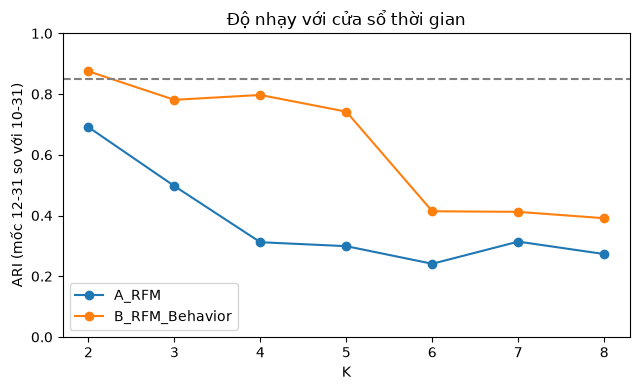

In [5]:
import matplotlib.pyplot as plt
raw = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]

# --- B ở mốc 10-31: nhóm Avg_Quantity cao còn không? ---
XB = SKScaler().fit_transform(u[MODELS["B_RFM_Behavior"]])
u["cB"] = SKMeans(4, n_init=20, random_state=0).fit_predict(XB)
pB = u.groupby("cB")[raw].median().round(2); pB.insert(0, "n", u.cB.value_counts().sort_index())
print("Profile B, mốc 10-31:\n", pB.to_string())
mB = u.merge(finals["B_RFM_Behavior"][["Survey_ResponseID", "cluster"]], on="Survey_ResponseID")
print("\nBảng chéo B (hàng = nhãn cuối, cột = nhãn mốc 10-31); nhóm mua theo lô là hàng 2:")
print(pd.crosstab(mB.cluster, mB.cB))

# --- Hình độ nhạy theo cửa sổ thời gian ---
os.makedirs(f"{OUT}/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(6.5, 4))
for n in sens.columns: ax.plot(sens.index, sens[n], marker="o", label=n)
ax.axhline(0.85, ls="--", c="gray"); ax.set_ylim(0, 1); ax.set_xlabel("K")
ax.set_ylabel("ARI (mốc 12-31 so với 10-31)"); ax.set_title("Độ nhạy với cửa sổ thời gian"); ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/figures/fig13_window_sensitivity.png", dpi=200); plt.show()

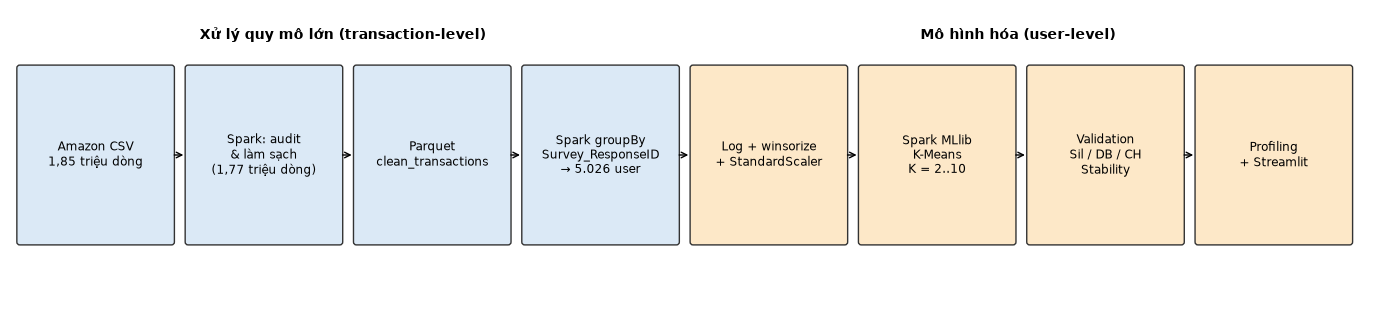

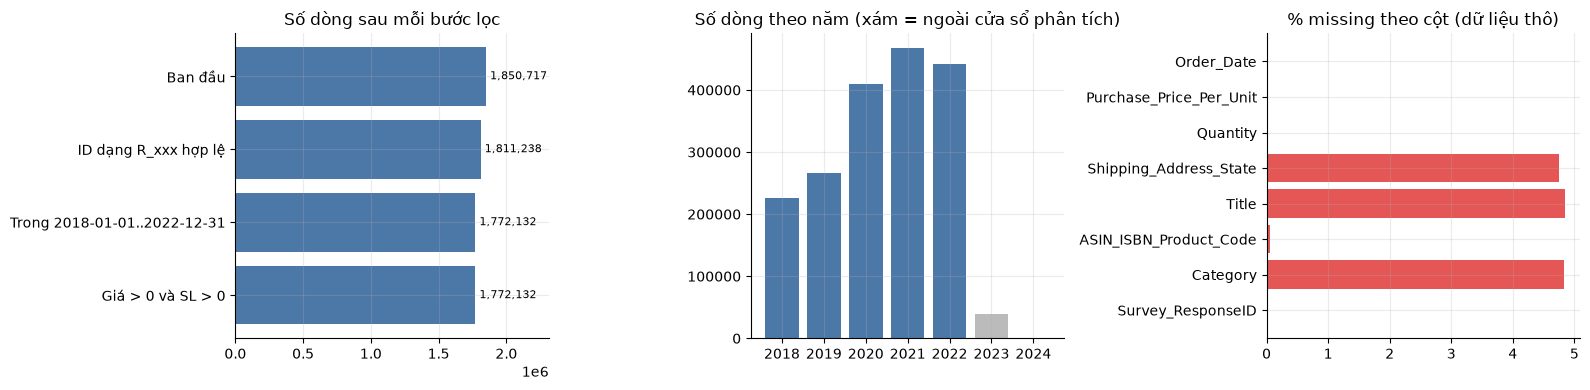

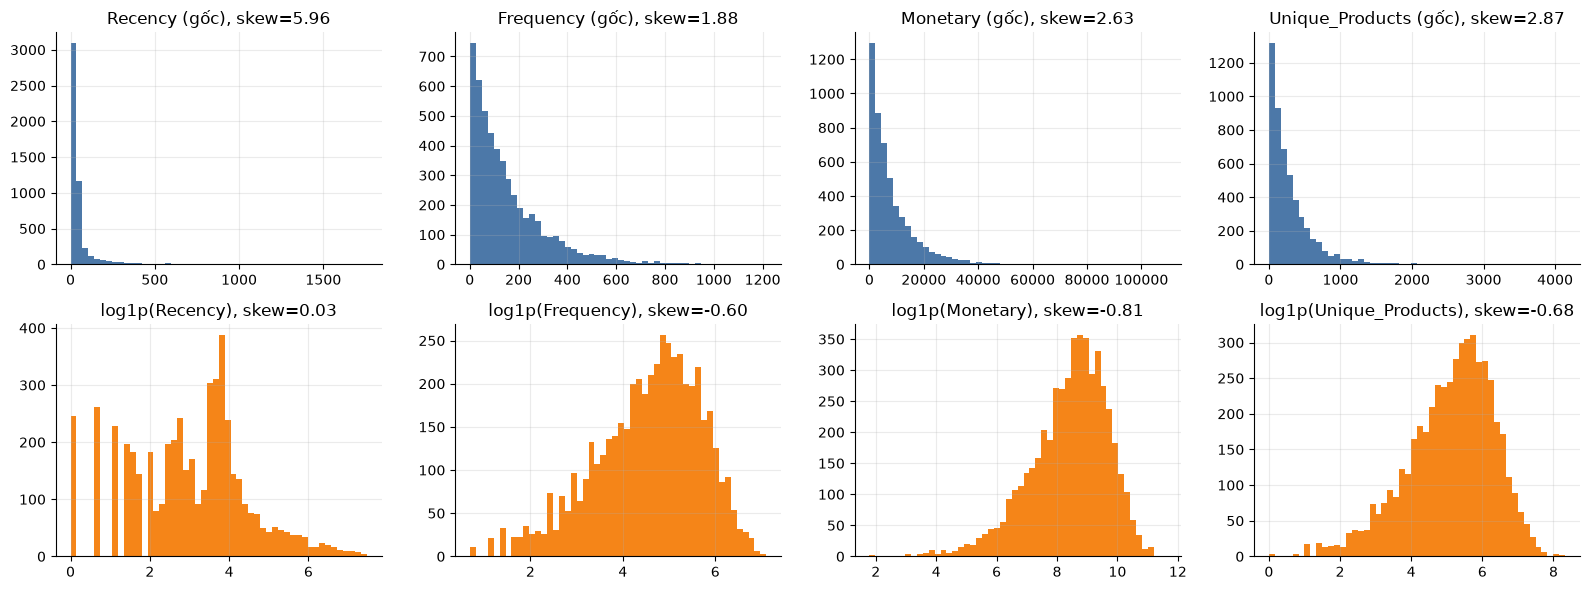

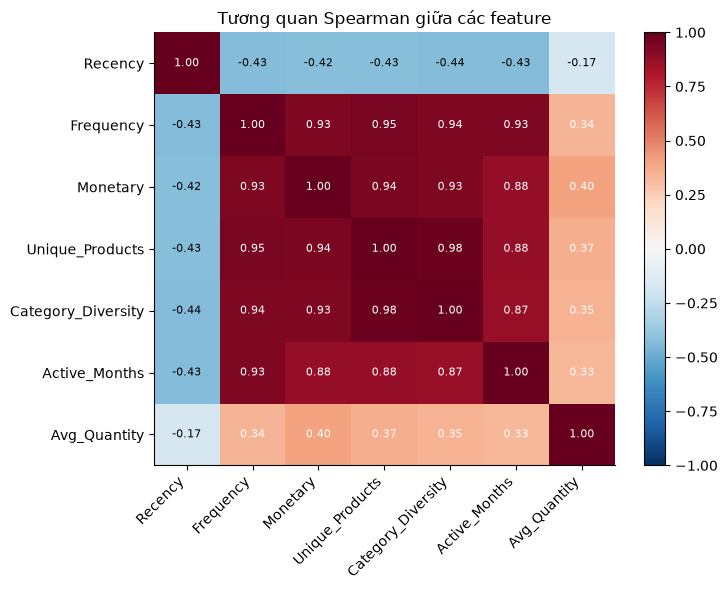

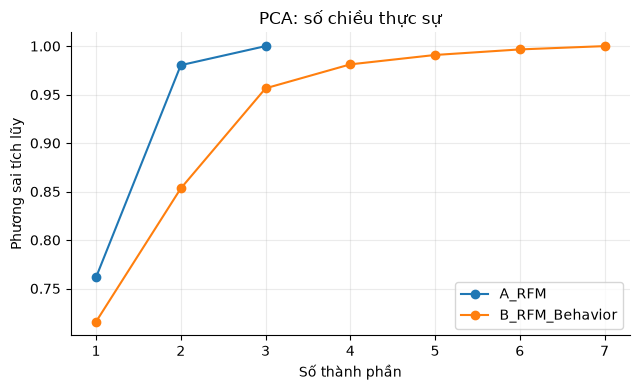

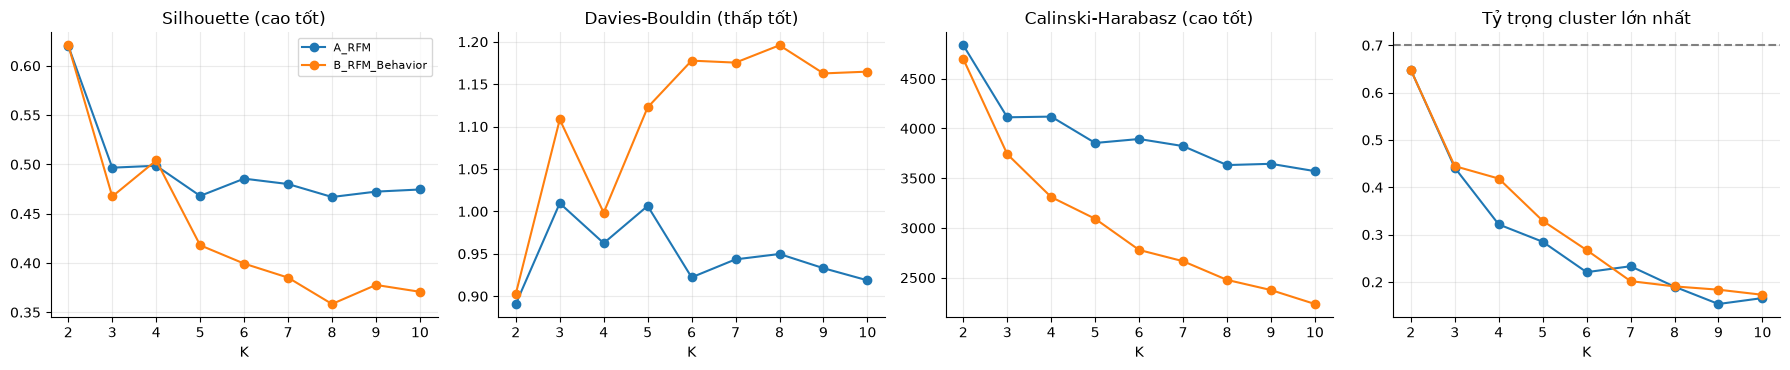

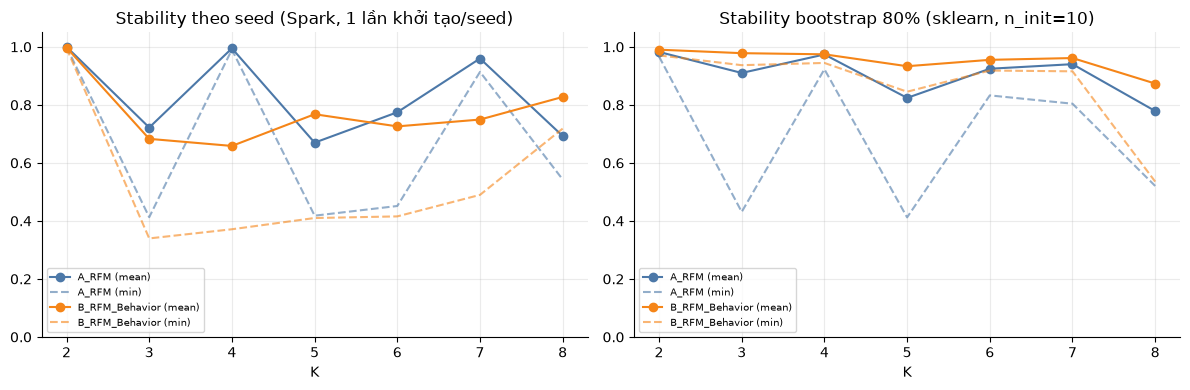

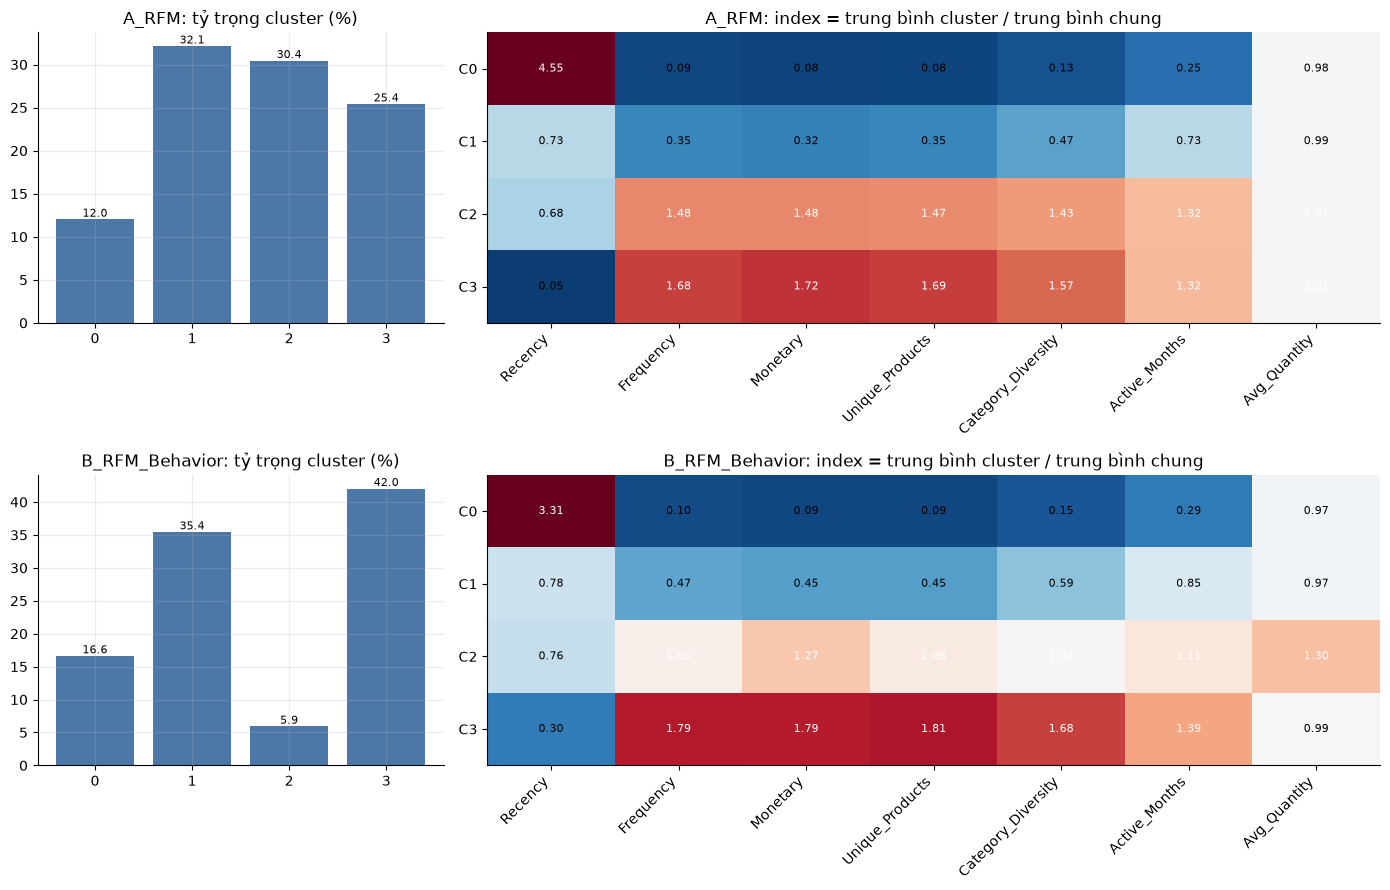

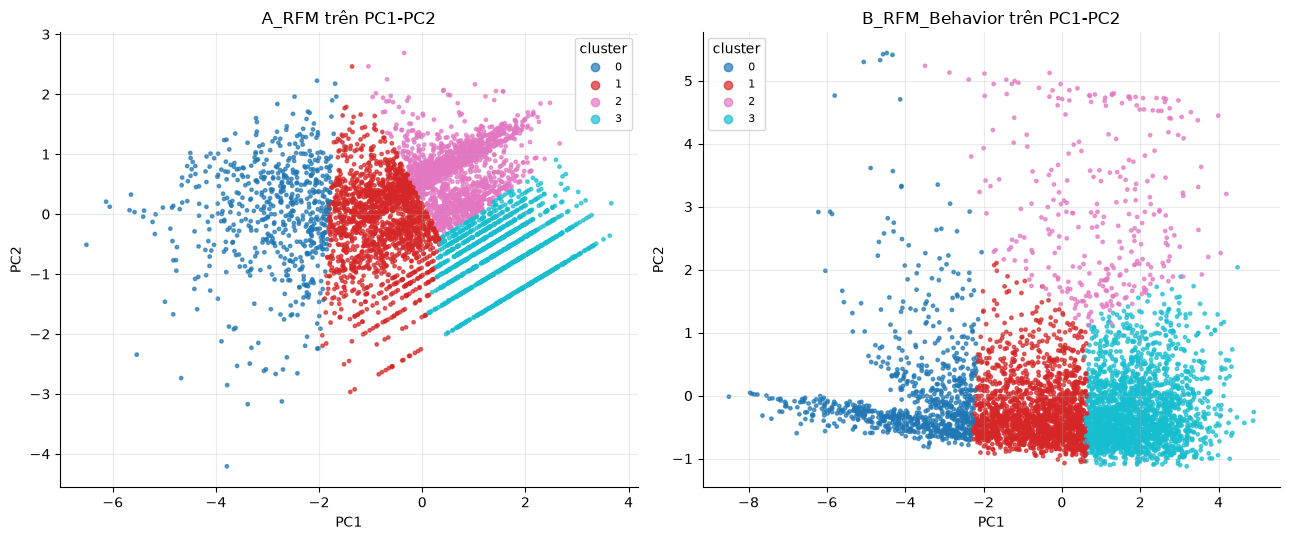

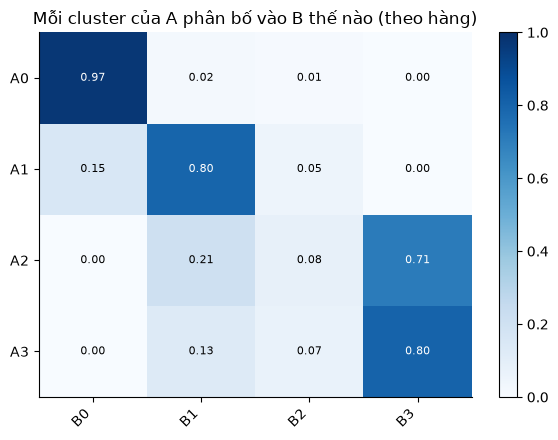

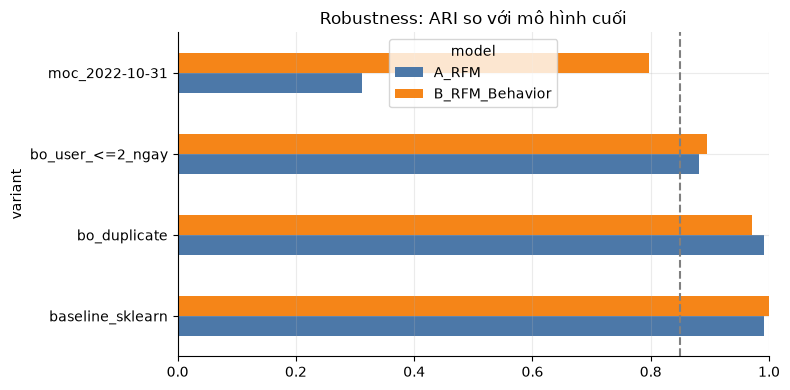

['fig01_pipeline.png', 'fig02_data_quality.png', 'fig03_log_transform.png', 'fig04_correlation.png', 'fig05_pca_variance.png', 'fig06_k_selection.png', 'fig07_stability.png', 'fig08_cluster_profiles.png', 'fig09_pca_scatter.png', 'fig10_A_vs_B.png', 'fig11_robustness.png', 'fig13_window_sensitivity.png']


In [6]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd, os
from matplotlib.patches import FancyBboxPatch
from sklearn.decomposition import PCA

FIG = f"{OUT}/figures"; os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({"axes.grid": True, "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
RAW = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]
MN = ["A_RFM", "B_RFM_Behavior"]

def save(name):
    plt.tight_layout(); plt.savefig(f"{FIG}/{name}.png", dpi=200, bbox_inches="tight"); plt.show()

def heat(ax, M, xl, yl, fmt="{:.2f}", cmap="Blues", vmin=None, vmax=None):
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(xl))); ax.set_xticklabels(xl, rotation=45, ha="right")
    ax.set_yticks(range(len(yl))); ax.set_yticklabels(yl); ax.grid(False)
    mid = (np.nanmin(M) + np.nanmax(M)) / 2 if vmin is None else (vmin + vmax) / 2
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if M[i, j] > mid else "black")
    return im

# ---------- Fig 1: Pipeline ----------
fig, ax = plt.subplots(figsize=(14, 3.2)); ax.axis("off"); ax.set_xlim(0, 14); ax.set_ylim(0, 3)
steps = ["Amazon CSV\n1,85 triệu dòng", "Spark: audit\n& làm sạch\n(1,77 triệu dòng)", "Parquet\nclean_transactions",
         "Spark groupBy\nSurvey_ResponseID\n→ 5.026 user", "Log + winsorize\n+ StandardScaler", "Spark MLlib\nK-Means\nK = 2..10",
         "Validation\nSil / DB / CH\nStability", "Profiling\n+ Streamlit"]
w = 1.55
for i, s in enumerate(steps):
    x = 0.1 + i * 1.72
    ax.add_patch(FancyBboxPatch((x, 0.6), w, 1.8, boxstyle="round,pad=0.03", fc="#dbe9f6" if i < 4 else "#fde8c8", ec="#333"))
    ax.text(x + w / 2, 1.5, s, ha="center", va="center", fontsize=8.5)
    if i < len(steps) - 1: ax.annotate("", xy=(x + w + 0.15, 1.5), xytext=(x + w, 1.5), arrowprops=dict(arrowstyle="->"))
ax.text(3.4, 2.7, "Xử lý quy mô lớn (transaction-level)", ha="center", fontsize=10, weight="bold")
ax.text(10.3, 2.7, "Mô hình hóa (user-level)", ha="center", fontsize=10, weight="bold")
save("fig01_pipeline")

# ---------- Fig 2: Data quality ----------
steps_df = pd.read_csv(f"{OUT}/audit/row_filter_steps.csv")
yr = pd.read_csv(f"{OUT}/audit/rows_by_year.csv")
miss = pd.read_csv(f"{OUT}/audit/missing_by_column.csv", index_col=0)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].barh(steps_df.step[::-1], steps_df.rows[::-1], color="#4c78a8"); ax[0].set_title("Số dòng sau mỗi bước lọc")
for i, v in enumerate(steps_df.rows[::-1]): ax[0].text(v, i, f" {v:,}", va="center", fontsize=8)
ax[0].set_xlim(0, steps_df.rows.max() * 1.25)
ax[1].bar(yr.year.astype(str), yr["count"], color=["#4c78a8" if y <= 2022 else "#bbb" for y in yr.year])
ax[1].set_title("Số dòng theo năm (xám = ngoài cửa sổ phân tích)")
ax[2].barh(miss.index[::-1], miss.pct[::-1], color="#e45756"); ax[2].set_title("% missing theo cột (dữ liệu thô)")
save("fig02_data_quality")

# ---------- Fig 3: Trước / sau log ----------
fig, ax = plt.subplots(2, 4, figsize=(16, 6))
for j, c in enumerate(["Recency", "Frequency", "Monetary", "Unique_Products"]):
    ax[0, j].hist(pdf[c], bins=50, color="#4c78a8"); ax[0, j].set_title(f"{c} (gốc), skew={pdf[c].skew():.2f}")
    l = np.log1p(pdf[c]); ax[1, j].hist(l, bins=50, color="#f58518"); ax[1, j].set_title(f"log1p({c}), skew={l.skew():.2f}")
save("fig03_log_transform")

# ---------- Fig 4: Tương quan ----------
corr = pdf[RAW].corr(method="spearman").values
fig, ax = plt.subplots(figsize=(7.5, 6))
im = heat(ax, corr, RAW, RAW, cmap="RdBu_r", vmin=-1, vmax=1); plt.colorbar(im, ax=ax)
ax.set_title("Tương quan Spearman giữa các feature")
save("fig04_correlation")

# ---------- Fig 5: PCA scree ----------
fig, ax = plt.subplots(figsize=(6.5, 4))
for n in MN:
    e = PCA().fit(Xs[n]).explained_variance_ratio_
    ax.plot(range(1, len(e) + 1), np.cumsum(e), marker="o", label=n)
ax.set_xlabel("Số thành phần"); ax.set_ylabel("Phương sai tích lũy"); ax.set_title("PCA: số chiều thực sự"); ax.legend()
save("fig05_pca_variance")

# ---------- Fig 6: Chọn K ----------
sw = pd.read_csv(f"{OUT}/validation/k_sweep.csv"); sw = sw[sw.model.isin(MN)]
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, (k, t) in zip(ax, [("silhouette", "Silhouette (cao tốt)"), ("davies_bouldin", "Davies-Bouldin (thấp tốt)"),
                           ("calinski_harabasz", "Calinski-Harabasz (cao tốt)"), ("max_share", "Tỷ trọng cluster lớn nhất")]):
    for n in MN: a.plot(sw[sw.model == n].k, sw[sw.model == n][k], marker="o", label=n)
    a.set_title(t); a.set_xlabel("K")
ax[0].legend(fontsize=8); ax[3].axhline(0.7, ls="--", c="gray")
save("fig06_k_selection")

# ---------- Fig 7: Stability ----------
st = pd.read_csv(f"{OUT}/stability/stability.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for n, col in zip(MN, ["#4c78a8", "#f58518"]):
    s = st[st.model == n]
    ax[0].plot(s.k, s.seed_ari_mean, marker="o", c=col, label=f"{n} (mean)"); ax[0].plot(s.k, s.seed_ari_min, ls="--", c=col, alpha=.6, label=f"{n} (min)")
    ax[1].plot(s.k, s.boot_ari_mean, marker="o", c=col, label=f"{n} (mean)"); ax[1].plot(s.k, s.boot_ari_min, ls="--", c=col, alpha=.6, label=f"{n} (min)")
ax[0].set_title("Stability theo seed (Spark, 1 lần khởi tạo/seed)"); ax[1].set_title("Stability bootstrap 80% (sklearn, n_init=10)")
for a in ax: a.set_xlabel("K"); a.set_ylim(0, 1.05); a.legend(fontsize=7)
save("fig07_stability")

# ---------- Fig 8: Cluster cuối: kích thước + profile index ----------
fig, ax = plt.subplots(2, 2, figsize=(14, 9), gridspec_kw={"width_ratios": [1, 2.2]})
for r, n in enumerate(MN):
    d = finals[n]; sh = d.cluster.value_counts(normalize=True).sort_index()
    ax[r, 0].bar(sh.index.astype(str), sh.values * 100, color="#4c78a8"); ax[r, 0].set_title(f"{n}: tỷ trọng cluster (%)")
    for i, v in enumerate(sh.values): ax[r, 0].text(i, v * 100, f"{v*100:.1f}", ha="center", va="bottom", fontsize=8)
    idx = (d.groupby("cluster")[RAW].mean() / d[RAW].mean())
    im = heat(ax[r, 1], idx.values, RAW, [f"C{c}" for c in idx.index], cmap="RdBu_r", vmin=0, vmax=2)
    ax[r, 1].set_title(f"{n}: index = trung bình cluster / trung bình chung")
save("fig08_cluster_profiles")

# ---------- Fig 9: Cluster trên không gian PCA 2D ----------
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for a, n in zip(ax, MN):
    Z = PCA(2).fit_transform(Xs[n]); c = finals[n].cluster.values
    sc = a.scatter(Z[:, 0], Z[:, 1], c=c, cmap="tab10", s=6, alpha=.7); a.set_title(f"{n} trên PC1-PC2")
    a.set_xlabel("PC1"); a.set_ylabel("PC2"); a.legend(*sc.legend_elements(), title="cluster", fontsize=8)
save("fig09_pca_scatter")

# ---------- Fig 10: A vs B ----------
ct = pd.crosstab(finals["A_RFM"].cluster, finals["B_RFM_Behavior"].cluster, normalize="index")
fig, ax = plt.subplots(figsize=(6, 4.5))
im = heat(ax, ct.values, [f"B{c}" for c in ct.columns], [f"A{c}" for c in ct.index], vmin=0, vmax=1); plt.colorbar(im, ax=ax)
ax.set_title("Mỗi cluster của A phân bố vào B thế nào (theo hàng)")
save("fig10_A_vs_B")

# ---------- Fig 11: Robustness (nếu đã chạy) ----------
p = f"{OUT}/final/robustness.csv"
if os.path.exists(p):
    rb = pd.read_csv(p).pivot(index="variant", columns="model", values="ARI_vs_final")
    ax = rb.plot.barh(figsize=(8, 4), color=["#4c78a8", "#f58518"]); ax.set_xlim(0, 1); ax.axvline(0.85, ls="--", c="gray")
    ax.set_title("Robustness: ARI so với mô hình cuối"); save("fig11_robustness")
print(sorted(os.listdir(FIG)))

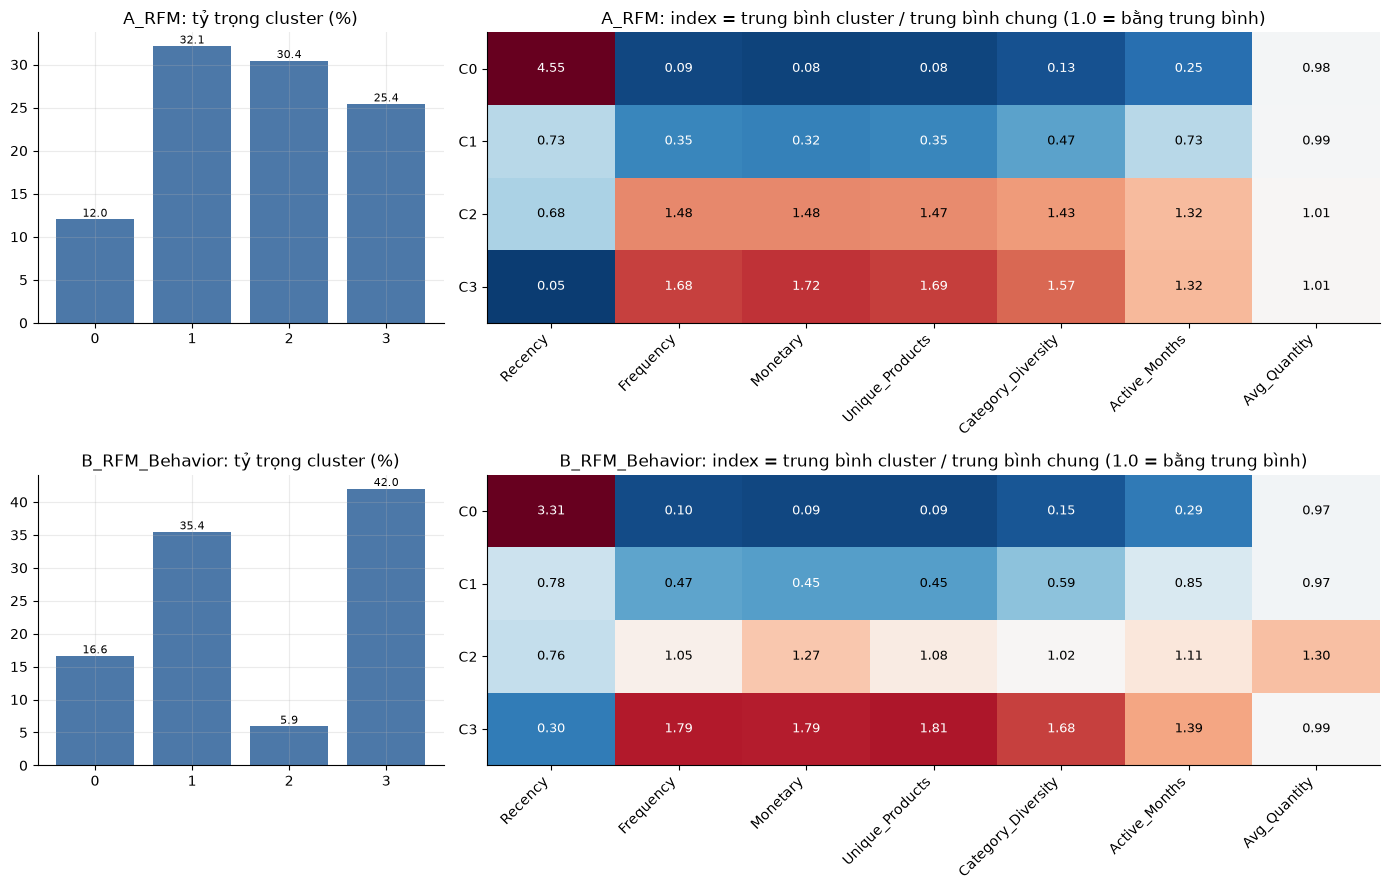

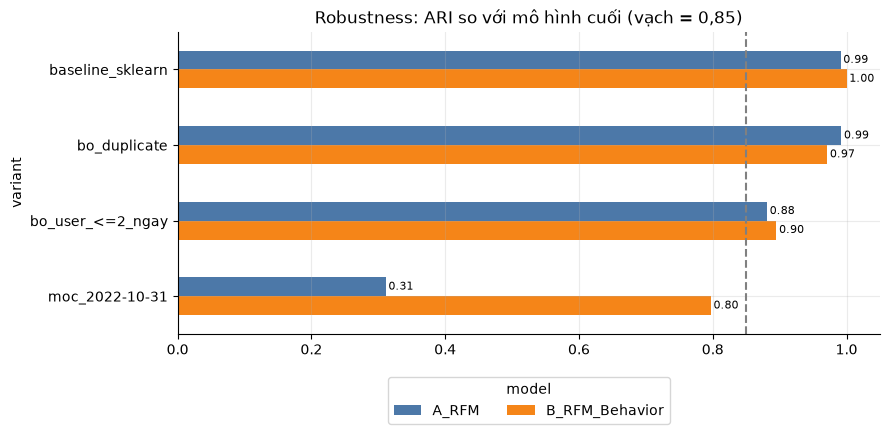

In [7]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd
RAW = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]
MN = ["A_RFM", "B_RFM_Behavior"]
FIG = f"{OUT}/figures"

# ---- Fig 8: chữ đen/trắng theo khoảng cách tới 1.0 ----
fig, ax = plt.subplots(2, 2, figsize=(14, 9), gridspec_kw={"width_ratios": [1, 2.2]})
for r, n in enumerate(MN):
    d = finals[n]; sh = d.cluster.value_counts(normalize=True).sort_index()
    ax[r, 0].bar(sh.index.astype(str), sh.values * 100, color="#4c78a8")
    ax[r, 0].set_title(f"{n}: tỷ trọng cluster (%)")
    for i, v in enumerate(sh.values): ax[r, 0].text(i, v * 100, f"{v*100:.1f}", ha="center", va="bottom", fontsize=8)
    idx = (d.groupby("cluster")[RAW].mean() / d[RAW].mean())
    a = ax[r, 1]; M = idx.values
    im = a.imshow(M, cmap="RdBu_r", vmin=0, vmax=2, aspect="auto"); a.grid(False)
    a.set_xticks(range(len(RAW))); a.set_xticklabels(RAW, rotation=45, ha="right")
    a.set_yticks(range(M.shape[0])); a.set_yticklabels([f"C{c}" for c in idx.index])
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            a.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=9,
                   color="white" if abs(M[i, j] - 1) > 0.55 else "black")
    a.set_title(f"{n}: index = trung bình cluster / trung bình chung (1.0 = bằng trung bình)")
plt.tight_layout(); plt.savefig(f"{FIG}/fig08_cluster_profiles.png", dpi=200, bbox_inches="tight"); plt.show()

# ---- Fig 11: legend ra ngoài ----
rb = pd.read_csv(f"{OUT}/final/robustness.csv").pivot(index="variant", columns="model", values="ARI_vs_final")
rb = rb.loc[["baseline_sklearn", "bo_duplicate", "bo_user_<=2_ngay", "moc_2022-10-31"]]
ax = rb.plot.barh(figsize=(9, 4.5), color=["#4c78a8", "#f58518"])
ax.set_xlim(0, 1.05); ax.axvline(0.85, ls="--", c="gray"); ax.invert_yaxis()
for c in ax.containers: ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
ax.legend(title="model", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.set_title("Robustness: ARI so với mô hình cuối (vạch = 0,85)")
plt.tight_layout(); plt.savefig(f"{FIG}/fig11_robustness.png", dpi=200, bbox_inches="tight"); plt.show()

In [8]:
names = {0: "Ít mua, lâu không quay lại", 1: "Mua mức trung bình",
         2: "Mua hàng tiêu dùng theo lô", 3: "Mua nhiều, hoạt động đều"}

# Kiểm tra nhãn khớp với bảng profile trước khi gán tên
chk = finals["B_RFM_Behavior"].groupby("cluster").agg(
    n=("Avg_Quantity", "size"), med_freq=("Frequency", "median"), med_avg_qty=("Avg_Quantity", "median")).round(2)
print(chk)   # kỳ vọng: cụm 2 có n≈298 và med_avg_qty≈1.29

fb = finals["B_RFM_Behavior"].copy()
fb["cluster_name"] = fb.cluster.map(names)
fb.to_csv(f"{OUT}/final/user_clusters_final.csv", index=False)
pd.Series(names, name="cluster_name").rename_axis("cluster").to_csv(f"{OUT}/final/cluster_names.csv")
print(fb.cluster_name.value_counts())

            n  med_freq  med_avg_qty
cluster                             
0         835      15.0         1.00
1        1781      70.0         1.03
2         298     128.0         1.29
3        2112     240.0         1.05
cluster_name
Mua nhiều, hoạt động đều      2112
Mua mức trung bình            1781
Ít mua, lâu không quay lại     835
Mua hàng tiêu dùng theo lô     298
Name: count, dtype: int64


In [9]:
import numpy as np, pandas as pd

bdf = finals["B_RFM_Behavior"]
niche_id = int(bdf.groupby("cluster")["Avg_Quantity"].median().idxmax())
print("Cluster nhóm theo lô:", niche_id)

lab = spark.createDataFrame(bdf[["Survey_ResponseID", "cluster"]].astype({"cluster": "int"}))
tx = (clean.join(lab, "Survey_ResponseID")
           .filter(F.col("Category").isNotNull())
           .withColumn("is_niche", (F.col("cluster") == niche_id).cast("int")))

agg = (tx.groupBy("Category", "is_niche")
         .agg(F.count("*").alias("lines"), F.sum("Quantity").alias("units"))
         .toPandas())

lines = agg.pivot(index="Category", columns="is_niche", values="lines").fillna(0)
units = agg.pivot(index="Category", columns="is_niche", values="units").fillna(0)
lines.columns = ["lines_rest", "lines_niche"]; units.columns = ["units_rest", "units_niche"]
t = lines.join(units)

for c in ["lines_niche", "lines_rest", "units_niche", "units_rest"]:
    t[c.replace("lines", "share_lines").replace("units", "share_units")] = t[c] / t[c].sum() * 100
t["lift_lines"] = t.share_lines_niche / t.share_lines_rest.replace(0, np.nan)
t["lift_units"] = t.share_units_niche / t.share_units_rest.replace(0, np.nan)
t.round(3).sort_values("units_niche", ascending=False).to_csv(f"{OUT}/profiling/category_niche_vs_rest.csv")

cols = ["lines_niche", "share_units_niche", "share_units_rest", "lift_units", "lift_lines"]
MIN_LINES = 300      # bỏ category quá hiếm để lift không bị nhiễu

print("\n[1] TOP 12 CATEGORY THEO TỶ TRỌNG ĐƠN VỊ CỦA NHÓM THEO LÔ")
print(t.sort_values("share_units_niche", ascending=False).head(12)[cols].round(2).to_string())

print(f"\n[2] TOP 12 CATEGORY CÓ LIFT CAO NHẤT (≥ {MIN_LINES} dòng trong nhóm)")
print(t[t.lines_niche >= MIN_LINES].sort_values("lift_units", ascending=False).head(12)[cols].round(2).to_string())

# Tổng quan: nhóm FMCG (thực phẩm, đồ uống, thú cưng) chiếm bao nhiêu đơn vị?
kw = "FOOD|GROCERY|VEGETABLE|DRINK|WATER|SNACK|PET|BEVERAGE|COFFEE|TEA|CEREAL"
fm = t.index.str.contains(kw)
print("\n[3] Category dạng thực phẩm/đồ uống/thú cưng (lọc theo từ khóa):")
print(f"  Tỷ trọng đơn vị: nhóm theo lô = {t.loc[fm,'share_units_niche'].sum():.1f}% | các nhóm còn lại = {t.loc[fm,'share_units_rest'].sum():.1f}%")

Cluster nhóm theo lô: 2

[1] TOP 12 CATEGORY THEO TỶ TRỌNG ĐƠN VỊ CỦA NHÓM THEO LÔ
                        lines_niche  share_units_niche  share_units_rest  lift_units  lift_lines
Category                                                                                        
ABIS_BOOK                    5234.0               4.41              4.98        0.89        0.80
PET_FOOD                     3626.0               3.31              2.29        1.44        1.34
FOOD                         2965.0               3.09              0.66        4.70        4.05
GROCERY                      2357.0               2.24              0.67        3.34        3.03
WALL_ART                      234.0               2.20              0.29        7.51        0.92
VEGETABLE                    2292.0               2.00              0.68        2.96        3.00
DRINK_FLAVORED               1540.0               1.52              0.57        2.66        2.38
FRUIT                        1687.0         

In [12]:
import time
def timed(fn):
    t0 = time.time(); fn(); return time.time() - t0
def run(tx):
    build_features(tx).write.format("noop").mode("overwrite").save()
def read_raw():
    spark.read.csv(RAW_CSV, header=True, inferSchema=True).write.format("noop").mode("overwrite").save()

run(clean.sample(fraction=0.05, seed=0))                 # khởi động, không tính
t_raw = min(timed(read_raw), timed(read_raw))
rows = []
for frac in [0.10, 0.25, 0.50, 1.00]:
    tx = clean if frac == 1.0 else clean.sample(fraction=frac, seed=1)
    n = tx.count()
    best = min(timed(lambda: run(tx)) for _ in range(2))
    rows.append(dict(fraction=frac, n_rows=n, seconds=round(best, 1)))
sc = pd.DataFrame(rows); sc["raw_csv_read_seconds"] = round(t_raw, 1)
sc.to_csv(f"{OUT}/validation/scalability.csv", index=False); print(sc)

   fraction   n_rows  seconds  raw_csv_read_seconds
0      0.10   176888      0.4                   0.8
1      0.25   441793      0.5                   0.8
2      0.50   885304      0.7                   0.8
3      1.00  1772132      0.8                   0.8


In [ ]:
import os, re, platform, subprocess, time
import numpy as np, pandas as pd
from pyspark.sql import functions as F

EXP = f"{OUT}/report_exports"; os.makedirs(EXP, exist_ok=True)
FEATS = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]
RAW_CSV = os.path.join(PROJECT, "amazon-purchases.csv")   # tên riêng, tránh trùng biến RAW cũ

def show(df, name, index=False):
    df.to_csv(f"{EXP}/{name}.csv", index=index)
    print(f"\n=== {name} ({df.shape[0]}x{df.shape[1]})"); print(df.round(4).to_string(max_rows=80))

for rel in ["validation/k_sweep.csv", "stability/stability.csv", "final/robustness.csv",
            "final/window_sensitivity.csv", "final/final_model_summary.csv",
            "audit/row_filter_steps.csv", "audit/rows_by_year.csv", "audit/quantiles.csv",
            "audit/missing_by_column.csv", "validation/scalability.csv"]:
    p = f"{OUT}/{rel}"
    if not os.path.exists(p): print("THIẾU:", p); continue
    t = pd.read_csv(p)
    if rel.endswith("k_sweep.csv"):
        print("Các model trong k_sweep.csv:", t.model.unique().tolist())
        t = t[t.model.isin(["A_RFM", "B_RFM_Behavior"])]
    show(t, "copy_" + os.path.basename(rel)[:-4])

print("\n=== Các tệp csv/json/png có trong OUT")
for root, _, fs in os.walk(OUT):
    for f in sorted(fs):
        if f.endswith((".csv", ".json", ".png")) and "report_exports" not in root:
            print(os.path.relpath(os.path.join(root, f), OUT))

In [ ]:
import os, re, platform, subprocess, time
import numpy as np, pandas as pd
from pyspark.sql import functions as F

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[1], line 5
    # Ensure notebook-level path variables exist even if this cell runs standalone
    if "PROJECT" not in globals():
        PROJECT = "/Users/quynhtien/Documents/Đồ án dự kiến"
    if "OUT" not in globals():
        OUT = os.path.join(PROJECT, "Dulieulon")

    os.makedirs(OUT, exist_ok=True)
    EXP = os.path.join(OUT, "report_exports")
    os.makedirs(EXP, exist_ok=True)

    FEATS = ["Recency", "Frequency", "Monetary", "Unique_Products",
             "Category_Diversity", "Active_Months", "Avg_Quantity"]
    RAW_CSV = os.path.join(PROJECT, "amazon-purchases.csv")
      2 import numpy as np, pandas as pd
      3 from pyspark.sql import functions as F
      4 
----> 5 EXP = f"{OUT}/report_exports"; os.makedirs(EXP, exist_ok=True)
      6 FEATS = ["Recency","Frequency","Monetary","Unique_Products","Category_Diversity","Active_Months","Avg_Quantity"]
      7 RAW_CSV = os.path.join(PROJECT, "amazon-purchases.csv")   # tên riêng, tránh trùng biến RAW cũ
      8 

NameError: name 'OUT' is not defined

SyntaxError: invalid syntax (2227156245.py, line 1)